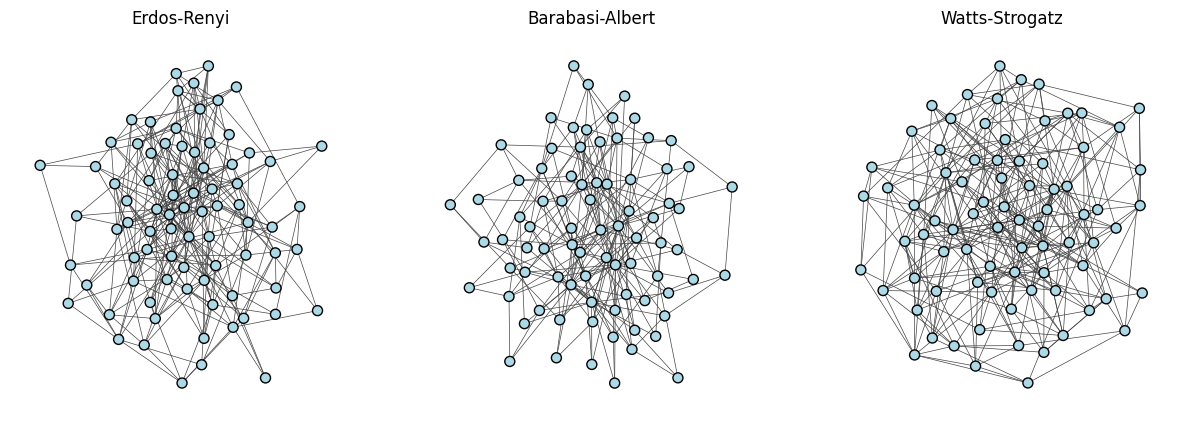

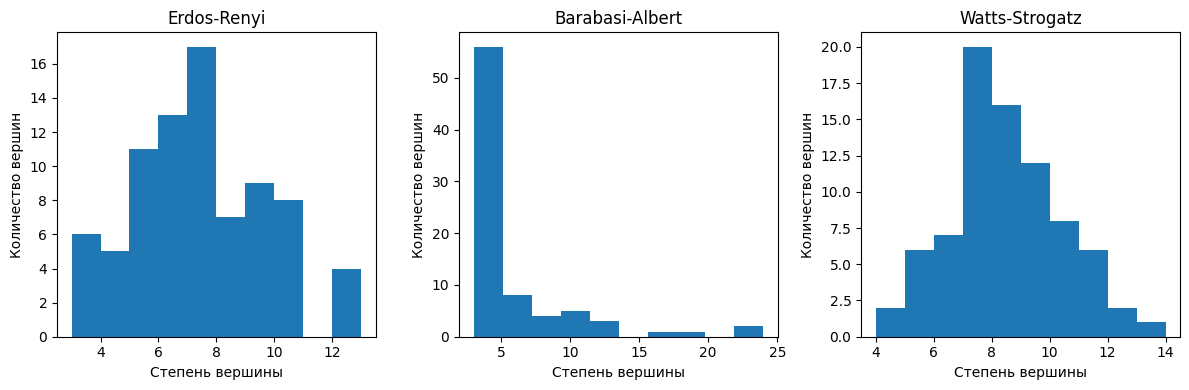

            Модель  Средняя кластеризация  Глобальная кластеризация  Диаметр  \
0      Erdos-Renyi               0.096174                  0.088424        4   
1  Barabasi-Albert               0.181622                  0.128874        5   
2   Watts-Strogatz               0.128586                  0.128033        4   

   Средняя длина пути  Плотность  Компоненты связности  \
0            2.440506   0.087975                     1   
1            2.532911   0.074051                     1   
2            2.332278   0.101266                     1   

   Размер гигантской компоненты  
0                            80  
1                            80  
2                            80  


In [3]:
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd

# параметры варианта 15
n = 80
p_er = 0.09
m_ba = 3
k_ws = 8
p_ws = 0.3


# ---------------------------
# Генерация графов
# ---------------------------

er_graph = ig.Graph.Erdos_Renyi(n=n, p=p_er)
ba_graph = ig.Graph.Barabasi(n=n, m=m_ba)
ws_graph = ig.Graph.Watts_Strogatz(dim=1, size=n, nei=k_ws//2, p=p_ws)

graphs = {
    "Erdos-Renyi": er_graph,
    "Barabasi-Albert": ba_graph,
    "Watts-Strogatz": ws_graph
}


# ---------------------------
# Функция вычисления параметров
# ---------------------------

def analyze_graph(graph):

    degrees = graph.degree()

    avg_clustering = graph.transitivity_avglocal_undirected()
    global_clustering = graph.transitivity_undirected()

    diameter = graph.diameter()
    avg_path_length = graph.average_path_length()

    density = graph.density()

    components = graph.components()
    num_components = len(components)
    giant_component_size = components.giant().vcount()

    return {
        "avg_clustering": avg_clustering,
        "global_clustering": global_clustering,
        "diameter": diameter,
        "avg_path_length": avg_path_length,
        "density": density,
        "num_components": num_components,
        "giant_component_size": giant_component_size,
        "degrees": degrees
    }


# ---------------------------
# Анализ графов
# ---------------------------

results = {}

for name, graph in graphs.items():
    results[name] = analyze_graph(graph)


# ---------------------------
# Визуализация графов
# ---------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, graph) in enumerate(graphs.items()):
    ig.plot(
        graph,
        target=axes[i],
        vertex_size=10,
        vertex_color="lightblue",
        edge_width=0.5,
        layout=graph.layout("fr")
    )
    axes[i].set_title(name)

plt.show()


# ---------------------------
# Гистограммы степеней
# ---------------------------

plt.figure(figsize=(12, 4))

for i, (name, data) in enumerate(results.items()):
    plt.subplot(1, 3, i + 1)
    plt.hist(data["degrees"], bins=10)
    plt.title(name)
    plt.xlabel("Степень вершины")
    plt.ylabel("Количество вершин")

plt.tight_layout()
plt.show()


# ---------------------------
# Таблица характеристик
# ---------------------------

table = []

for name, data in results.items():
    table.append([
        name,
        data["avg_clustering"],
        data["global_clustering"],
        data["diameter"],
        data["avg_path_length"],
        data["density"],
        data["num_components"],
        data["giant_component_size"]
    ])

df = pd.DataFrame(table, columns=[
    "Модель",
    "Средняя кластеризация",
    "Глобальная кластеризация",
    "Диаметр",
    "Средняя длина пути",
    "Плотность",
    "Компоненты связности",
    "Размер гигантской компоненты"
])

print(df)